In [1]:
import pandas as pd
import numpy as np


In [2]:
pwd

'/gpfs/data/arsoyd01lab/machlm03/Segmentation/MedSAM2/oai_utils'

In [3]:
df=pd.read_csv("/gpfs/home/machlm03/Segmentation/MedSAM2/oai_utils/updated_results/OAI_IWOAI_Inference2.2_per_slice.csv")

In [4]:
# Ensure 'case' stays as string
df["case"] = df["case"].astype(str)

# Replace 'inf' and empty strings with NaN
df.replace(["inf", ""], np.nan, inplace=True)

# Convert only metric columns to numeric
metric_cols = df.columns.difference(["case", "slice"])
df[metric_cols] = df[metric_cols].apply(pd.to_numeric, errors="coerce")

# Select Dice and IoU columns
dice_iou_cols = [col for col in metric_cols if "dice" in col.lower() or "iou" in col.lower()]

# Group by case and compute mean
case_means = df.groupby("case")[dice_iou_cols].mean().round(4)
case_means=case_means.reset_index(drop=False)
# Optional: count valid entries per column
# case_counts = df.groupby(

case_means


,case,Femoral Cartilage_dice,Femoral Cartilage_iou,Femur_dice,Femur_iou,Meniscus_dice,Meniscus_iou,Patella_dice,Patella_iou,Patellar Cartilage_dice,Patellar Cartilage_iou,Tibia_dice,Tibia_iou,Tibial Cartilage_dice,Tibial Cartilage_iou,mean_dice,mean_iou
0,9000099_00m_LEFT_SAG_3D_DESS_WE,0.9237,0.8672,0.9726,0.9550,0.9302,0.8784,0.9322,0.9112,0.8534,0.7795,0.9593,0.9360,0.8323,0.7365,0.8981,0.8489
1,9002411_00m_LEFT_SAG_3D_DESS_WE,0.9281,0.8810,0.9747,0.9599,0.9445,0.8966,0.9649,0.9360,0.8909,0.8277,0.9529,0.9331,0.8862,0.8285,0.9122,0.8720
2,9002411_00m_RIGHT_SAG_3D_DESS_WE,0.9475,0.9064,0.9730,0.9581,0.9173,0.8723,0.9168,0.8872,0.8960,0.8394,0.9784,0.9609,0.8965,0.8383,0.9308,0.8923
3,9003175_00m_LEFT_SAG_3D_DESS_WE,0.9447,0.8980,0.9752,0.9613,0.9114,0.8596,0.9546,0.9362,0.9138,0.8503,0.9822,0.9670,0.8774,0.8163,0.9188,0.8812
4,9003175_00m_RIGHT_SAG_3D_DESS_WE,0.9297,0.8829,0.9819,0.9658,0.9237,0.8608,0.9506,0.9297,0.9223,0.8660,0.9756,0.9567,0.8792,0.8160,0.9199,0.8788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705,9997610_00m_RIGHT_SAG_3D_DESS_WE,0.9261,0.8757,0.9729,0.9567,0.8678,0.7819,0.9641,0.9400,0.9040,0.8589,0.9689,0.9498,0.8811,0.8312,0.9188,0.8779
1706,9997856_00m_LEFT_SAG_3D_DESS_WE,0.9080,0.8491,0.9760,0.9577,0.9102,0.8569,0.9340,0.9033,0.7935,0.7091,0.9607,0.9419,0.8406,0.7752,0.8846,0.8354
1707,9997856_00m_RIGHT_SAG_3D_DESS_WE,0.9258,0.8784,0.9746,0.9590,0.9436,0.9076,0.9424,0.9243,0.9112,0.8554,0.9476,0.9282,0.9073,0.8550,0.9198,0.8828
1708,9999862_00m_LEFT_SAG_3D_DESS_WE,0.9231,0.8645,0.9789,0.9646,0.9399,0.8891,0.9600,0.9346,0.9149,0.8645,0.9827,0.9673,0.9030,0.8452,0.9347,0.8948


In [5]:
dfkl=pd.read_csv("/gpfs/home/machlm03/Segmentation/MedSAM2/oai_utils/results/split_dataset_70_10_20_with_cv.csv")
dfkl=dfkl[dfkl['split']=='test']

In [6]:
dfkl=dfkl[['File_Name','ID','V00XRKL','split']]

In [7]:

# Extract ID and laterality to match File_Name
case_means["File_Name"] = case_means["case"].str.extract(r"(\d+)_00m_(LEFT|RIGHT)")[0] + "_" + \
                         case_means["case"].str.extract(r"(\d+)_00m_(LEFT|RIGHT)")[1]



In [8]:
case_means

,case,Femoral Cartilage_dice,Femoral Cartilage_iou,Femur_dice,Femur_iou,Meniscus_dice,Meniscus_iou,Patella_dice,Patella_iou,Patellar Cartilage_dice,Patellar Cartilage_iou,Tibia_dice,Tibia_iou,Tibial Cartilage_dice,Tibial Cartilage_iou,mean_dice,mean_iou,File_Name
0,9000099_00m_LEFT_SAG_3D_DESS_WE,0.9237,0.8672,0.9726,0.9550,0.9302,0.8784,0.9322,0.9112,0.8534,0.7795,0.9593,0.9360,0.8323,0.7365,0.8981,0.8489,9000099_LEFT
1,9002411_00m_LEFT_SAG_3D_DESS_WE,0.9281,0.8810,0.9747,0.9599,0.9445,0.8966,0.9649,0.9360,0.8909,0.8277,0.9529,0.9331,0.8862,0.8285,0.9122,0.8720,9002411_LEFT
2,9002411_00m_RIGHT_SAG_3D_DESS_WE,0.9475,0.9064,0.9730,0.9581,0.9173,0.8723,0.9168,0.8872,0.8960,0.8394,0.9784,0.9609,0.8965,0.8383,0.9308,0.8923,9002411_RIGHT
3,9003175_00m_LEFT_SAG_3D_DESS_WE,0.9447,0.8980,0.9752,0.9613,0.9114,0.8596,0.9546,0.9362,0.9138,0.8503,0.9822,0.9670,0.8774,0.8163,0.9188,0.8812,9003175_LEFT
4,9003175_00m_RIGHT_SAG_3D_DESS_WE,0.9297,0.8829,0.9819,0.9658,0.9237,0.8608,0.9506,0.9297,0.9223,0.8660,0.9756,0.9567,0.8792,0.8160,0.9199,0.8788,9003175_RIGHT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705,9997610_00m_RIGHT_SAG_3D_DESS_WE,0.9261,0.8757,0.9729,0.9567,0.8678,0.7819,0.9641,0.9400,0.9040,0.8589,0.9689,0.9498,0.8811,0.8312,0.9188,0.8779,9997610_RIGHT
1706,9997856_00m_LEFT_SAG_3D_DESS_WE,0.9080,0.8491,0.9760,0.9577,0.9102,0.8569,0.9340,0.9033,0.7935,0.7091,0.9607,0.9419,0.8406,0.7752,0.8846,0.8354,9997856_LEFT
1707,9997856_00m_RIGHT_SAG_3D_DESS_WE,0.9258,0.8784,0.9746,0.9590,0.9436,0.9076,0.9424,0.9243,0.9112,0.8554,0.9476,0.9282,0.9073,0.8550,0.9198,0.8828,9997856_RIGHT
1708,9999862_00m_LEFT_SAG_3D_DESS_WE,0.9231,0.8645,0.9789,0.9646,0.9399,0.8891,0.9600,0.9346,0.9149,0.8645,0.9827,0.9673,0.9030,0.8452,0.9347,0.8948,9999862_LEFT


In [9]:
# dfkl=dfkl[['File_Name','V00XRKL']]
merged_df = pd.merge(case_means, dfkl, on="File_Name", how="left")

In [10]:
merged_df

,case,Femoral Cartilage_dice,Femoral Cartilage_iou,Femur_dice,Femur_iou,Meniscus_dice,Meniscus_iou,Patella_dice,Patella_iou,Patellar Cartilage_dice,...,Tibia_dice,Tibia_iou,Tibial Cartilage_dice,Tibial Cartilage_iou,mean_dice,mean_iou,File_Name,ID,V00XRKL,split
0,9000099_00m_LEFT_SAG_3D_DESS_WE,0.9237,0.8672,0.9726,0.9550,0.9302,0.8784,0.9322,0.9112,0.8534,...,0.9593,0.9360,0.8323,0.7365,0.8981,0.8489,9000099_LEFT,9000099,3.0,test
1,9002411_00m_LEFT_SAG_3D_DESS_WE,0.9281,0.8810,0.9747,0.9599,0.9445,0.8966,0.9649,0.9360,0.8909,...,0.9529,0.9331,0.8862,0.8285,0.9122,0.8720,9002411_LEFT,9002411,2.0,test
2,9002411_00m_RIGHT_SAG_3D_DESS_WE,0.9475,0.9064,0.9730,0.9581,0.9173,0.8723,0.9168,0.8872,0.8960,...,0.9784,0.9609,0.8965,0.8383,0.9308,0.8923,9002411_RIGHT,9002411,2.0,test
3,9003175_00m_LEFT_SAG_3D_DESS_WE,0.9447,0.8980,0.9752,0.9613,0.9114,0.8596,0.9546,0.9362,0.9138,...,0.9822,0.9670,0.8774,0.8163,0.9188,0.8812,9003175_LEFT,9003175,0.0,test
4,9003175_00m_RIGHT_SAG_3D_DESS_WE,0.9297,0.8829,0.9819,0.9658,0.9237,0.8608,0.9506,0.9297,0.9223,...,0.9756,0.9567,0.8792,0.8160,0.9199,0.8788,9003175_RIGHT,9003175,0.0,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1705,9997610_00m_RIGHT_SAG_3D_DESS_WE,0.9261,0.8757,0.9729,0.9567,0.8678,0.7819,0.9641,0.9400,0.9040,...,0.9689,0.9498,0.8811,0.8312,0.9188,0.8779,9997610_RIGHT,9997610,2.0,test
1706,9997856_00m_LEFT_SAG_3D_DESS_WE,0.9080,0.8491,0.9760,0.9577,0.9102,0.8569,0.9340,0.9033,0.7935,...,0.9607,0.9419,0.8406,0.7752,0.8846,0.8354,9997856_LEFT,9997856,4.0,test
1707,9997856_00m_RIGHT_SAG_3D_DESS_WE,0.9258,0.8784,0.9746,0.9590,0.9436,0.9076,0.9424,0.9243,0.9112,...,0.9476,0.9282,0.9073,0.8550,0.9198,0.8828,9997856_RIGHT,9997856,0.0,test
1708,9999862_00m_LEFT_SAG_3D_DESS_WE,0.9231,0.8645,0.9789,0.9646,0.9399,0.8891,0.9600,0.9346,0.9149,...,0.9827,0.9673,0.9030,0.8452,0.9347,0.8948,9999862_LEFT,9999862,2.0,test


In [11]:
# Group by fold and calculate mean and std
dice_iou_cols = [col for col in merged_df if "dice" in col.lower() or "iou" in col.lower()]

summary = merged_df.groupby("V00XRKL")[dice_iou_cols].agg(['mean', 'std']).round(4)

# # Flatten multi-level columns
summary.columns = ['_'.join(col) for col in summary.columns]
summary = summary.reset_index()




summary.to_csv("KL_grade_result.csv",index=False)

In [12]:
# Set voxel index as row label
import matplotlib.pyplot as plt

import seaborn as sns
hm=summary
hm.set_index("V00XRKL", inplace=True)
# hm = hm.drop(columns=["mean_iou_std","mean_iou_mean","mean_dice_mean","mean_dice_std"])



In [13]:
hm.columns

Index(['Femoral Cartilage_dice_mean', 'Femoral Cartilage_dice_std',
       'Femoral Cartilage_iou_mean', 'Femoral Cartilage_iou_std',
       'Femur_dice_mean', 'Femur_dice_std', 'Femur_iou_mean', 'Femur_iou_std',
       'Meniscus_dice_mean', 'Meniscus_dice_std', 'Meniscus_iou_mean',
       'Meniscus_iou_std', 'Patella_dice_mean', 'Patella_dice_std',
       'Patella_iou_mean', 'Patella_iou_std', 'Patellar Cartilage_dice_mean',
       'Patellar Cartilage_dice_std', 'Patellar Cartilage_iou_mean',
       'Patellar Cartilage_iou_std', 'Tibia_dice_mean', 'Tibia_dice_std',
       'Tibia_iou_mean', 'Tibia_iou_std', 'Tibial Cartilage_dice_mean',
       'Tibial Cartilage_dice_std', 'Tibial Cartilage_iou_mean',
       'Tibial Cartilage_iou_std', 'mean_dice_mean', 'mean_dice_std',
       'mean_iou_mean', 'mean_iou_std'],
      dtype='object')

In [14]:

# Select Dice mean columns
# Clean Dice column names


dice_cols = [col for col in hm.columns if col.endswith("_dice_mean")]
dice_data = hm[dice_cols]

# Select IoU mean columns
iou_cols = [col for col in hm.columns if col.endswith("_iou_mean")]
iou_data = hm[iou_cols]

dice_data.columns = [col.replace("_dice_mean", "") for col in dice_data.columns]

# Clean IoU column names
iou_data.columns = [col.replace("_iou_mean", "") for col in iou_data.columns]


/tmp/ipykernel_2537941/3357118807.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')


[Text(0.5, 0, 'Femoral Cartilage'),
 Text(1.5, 0, 'Femur'),
 Text(2.5, 0, 'Meniscus'),
 Text(3.5, 0, 'Patella'),
 Text(4.5, 0, 'Patellar Cartilage'),
 Text(5.5, 0, 'Tibia'),
 Text(6.5, 0, 'Tibial Cartilage'),
 Text(7.5, 0, 'mean')]

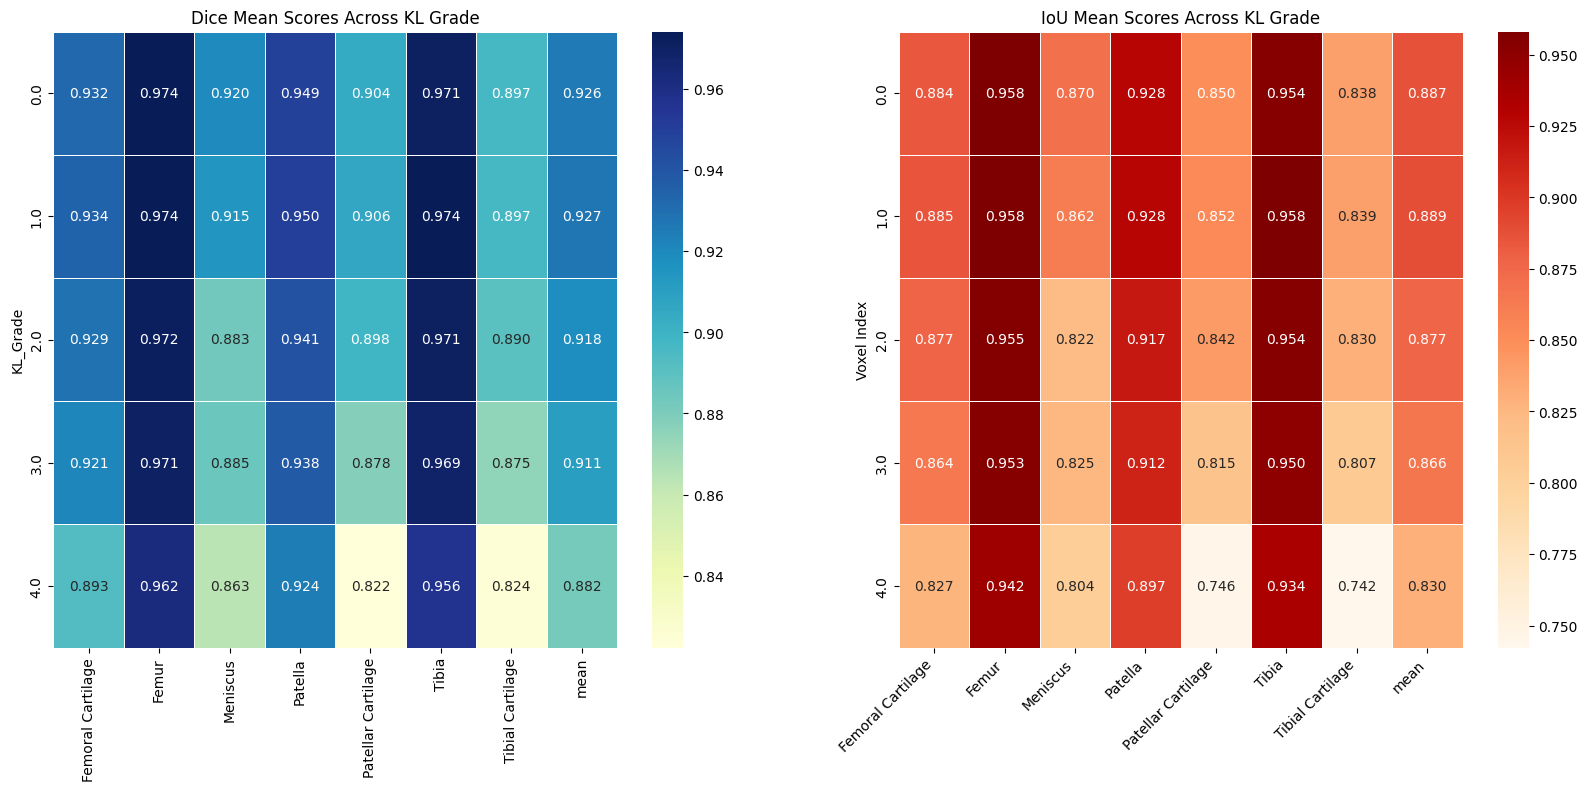

In [18]:
# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(dice_data, ax=axes[0], cmap="YlGnBu", annot=True, fmt=".3f", linewidths=0.5)
axes[0].set_title("Dice Mean Scores Across KL Grade")
# axes[0].set_xlabel("Structure")
axes[0].set_ylabel("KL_Grade")
axes[1].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')


sns.heatmap(iou_data, ax=axes[1], cmap="OrRd", annot=True, fmt=".3f", linewidths=0.5)
axes[1].set_title("IoU Mean Scores Across KL Grade")
axes[1].set_xlabel("")
axes[1].set_ylabel("Voxel Index")

axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
